# AIME in 5 Minutes — Titanic Quick Start

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ntakafumi/aime/blob/main/examples/colab/01_titanic_quickstart.ipynb)

Train a black-box classifier and explain it with **AIME (Approximate Inverse Model Explanations)**. AIME learns one approximate inverse operator `A†` from model outputs back to input features.

This notebook produces:

- per-class **global feature importance**,
- **local feature importance** for one passenger,
- a **local Hadamard decomposition**,
- class-wise **representative input patterns**, and
- an **inverse-operator flow** visualization.

A CPU runtime is sufficient; no GPU is required.


## 0. Install AIME

The notebook is tested against `aime-xai==1.2.0`. The conditional installer avoids reinstalling it when it is already available.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("aime_xai") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "aime-xai==1.2.0"
    ])


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

import aime_xai
from aime_xai import AIME
import aime_xai.style as S

# Educational notebooks benefit from in-figure titles and captions.
S.set_publication_mode(False)

print("aime_xai version:", aime_xai.__version__)


aime_xai version: 1.2.0


## 1. Load and prepare Titanic

The data source is the public Titanic CSV used by the seaborn examples. Missing continuous values are median-imputed, and categorical variables are one-hot encoded.


In [3]:
DATA_SOURCE = os.environ.get(
    "AIME_TITANIC_CSV",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
)
titanic = pd.read_csv(DATA_SOURCE)

def prepare_titanic(df: pd.DataFrame):
    data = df[
        ["survived", "age", "sibsp", "parch", "fare", "pclass", "sex", "embarked"]
    ].copy()

    data["age"] = data["age"].fillna(data["age"].median())
    data["fare"] = data["fare"].fillna(data["fare"].median())
    data["embarked"] = data["embarked"].fillna(data["embarked"].mode().iloc[0])

    data = data.rename(columns={
        "age": "Age", "sibsp": "SibSp", "parch": "Parch", "fare": "Fare",
        "pclass": "Pclass", "sex": "Sex", "embarked": "Emb",
    })
    data["Pclass"] = data["Pclass"].astype(int).astype(str)

    X = pd.get_dummies(
        data.drop(columns="survived"),
        columns=["Pclass", "Sex", "Emb"],
        dtype=float,
    )
    feature_order = [
        "Age", "SibSp", "Parch", "Fare",
        "Pclass_1", "Pclass_2", "Pclass_3",
        "Sex_female", "Sex_male",
        "Emb_C", "Emb_Q", "Emb_S",
    ]
    X = X.reindex(columns=feature_order, fill_value=0.0).astype(float)
    y = data["survived"].astype(int)
    return X, y

X, y = prepare_titanic(titanic)
feature_names = X.columns.tolist()
class_names = ["not survived", "survived"]

print("X shape:", X.shape)
display(pd.DataFrame({"count": y.value_counts().sort_index()}, index=[0, 1]))
display(X.head(3))


X shape: (891, 12)


,count
0,549
1,342


,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Emb_C,Emb_Q,Emb_S
0,22.0,1.0,0.0,7.2500,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,38.0,1.0,0.0,71.2833,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,26.0,0.0,0.0,7.9250,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


## 2. Train a black-box model

AIME is model-agnostic: it uses the model's `predict_proba` output and does not inspect the model internals.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_hat_train = model.predict_proba(X_train)
y_hat_test = model.predict_proba(X_test)

metrics = pd.Series({
    "test accuracy": accuracy_score(y_test, model.predict(X_test)),
    "test ROC AUC": roc_auc_score(y_test, y_hat_test[:, 1]),
})
display(metrics.to_frame("value").round(3))


,value
test accuracy,0.807
test ROC AUC,0.840


## 3. Learn the approximate inverse operator `A†`

With `d` input features and `m` output classes, `A†` has shape `(d, m)`. Every explanation below is derived from this one fitted operator.


In [5]:
explainer = AIME().create_explainer(
    X_train, y_hat_train, normalize=True
)

print("variant:", explainer.variant_name)
print("A† shape:", explainer.A_dagger.shape, "= (features, classes)")


variant: AIME
A† shape: (12, 2) = (features, classes)


## 4. Global feature importance — one signed vector per output class

Each column of `A†` describes how a class output maps back to the input-feature space. Strong negative weights are as meaningful as strong positive weights.


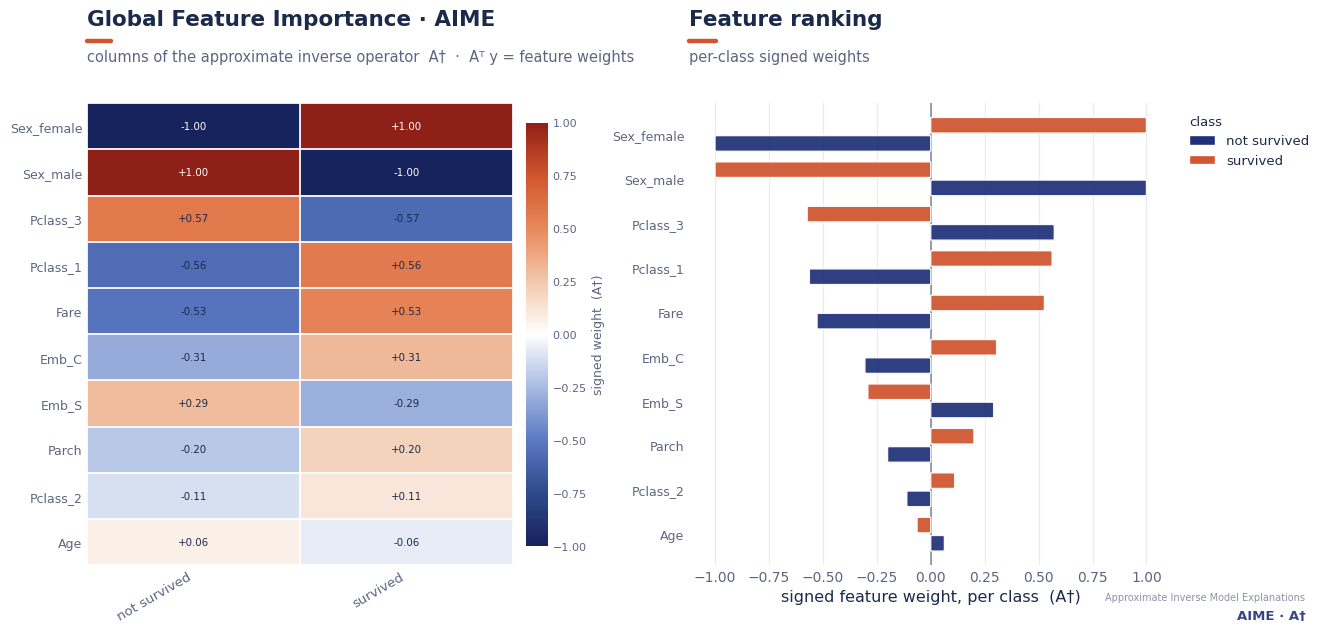

,Sex_female,Sex_male,Pclass_3,Pclass_1,Fare,Emb_C,Emb_S,Parch,Pclass_2,Age
not survived,-1.0,1.0,0.57,-0.56,-0.53,-0.31,0.29,-0.2,-0.11,0.06
survived,1.0,-1.0,-0.57,0.56,0.53,0.31,-0.29,0.2,0.11,-0.06


In [6]:
global_importance = explainer.global_feature_importance(
    feature_names=feature_names,
    class_names=class_names,
    top_k=10,
    layout="horizontal",
)

display(global_importance.round(2))


## 5. Local explanation — one passenger

We select the test passenger with the largest predicted survival probability. AIME's local rule is the Hadamard product

`local importance = (A† y) ⊙ x′`,

where `x′` is the standardized input and `y` is this passenger's prediction vector.


In [7]:
focus_position = int(np.argmax(y_hat_test[:, 1]))
focus_x = X_test.iloc[focus_position].to_numpy(dtype=float)
focus_y = y_hat_test[focus_position]

print("predicted probabilities:")
display(pd.Series(focus_y, index=class_names, name="probability").to_frame().round(3))

print("passenger features:")
display(pd.Series(focus_x, index=feature_names, name="value").to_frame().T)


predicted probabilities:


,probability
not survived,0.011
survived,0.989


passenger features:


,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Emb_C,Emb_Q,Emb_S
value,33.0,0.0,0.0,86.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


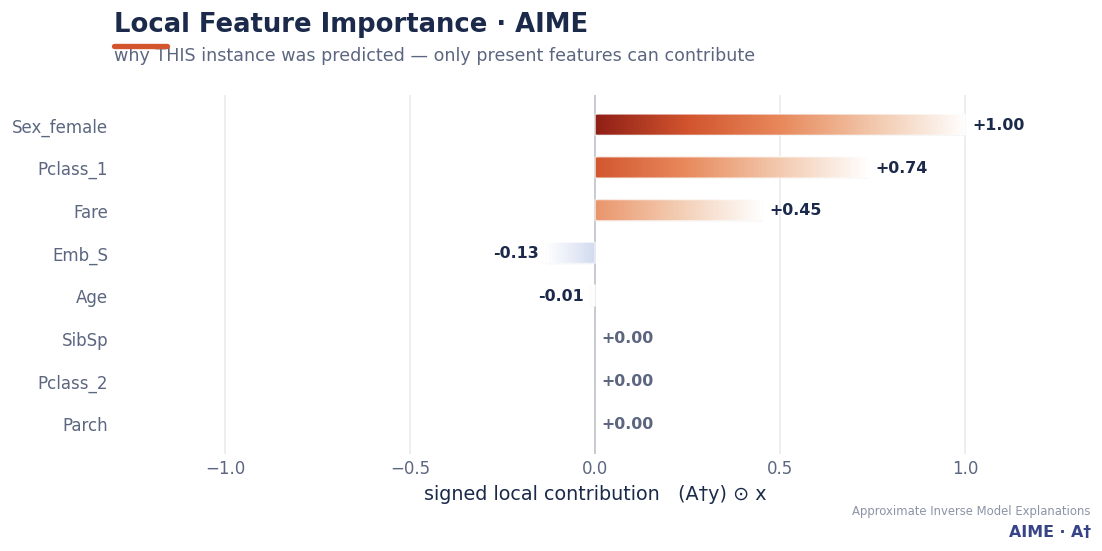

,Sex_female,Pclass_1,Fare,Emb_S,Age,SibSp,Parch,Pclass_2
0,1.0,0.74,0.45,-0.13,-0.01,-0.0,-0.0,-0.0


In [8]:
local_importance = explainer.local_feature_importance(
    focus_x,
    focus_y,
    feature_names=feature_names,
    scaler=explainer.scaler,
    top_k=8,
    ignore_zero_features=True,
)

display(local_importance.round(2))


The decomposition below makes the local rule explicit: the class-conditioned global pull is multiplied feature-by-feature by the passenger's own input.


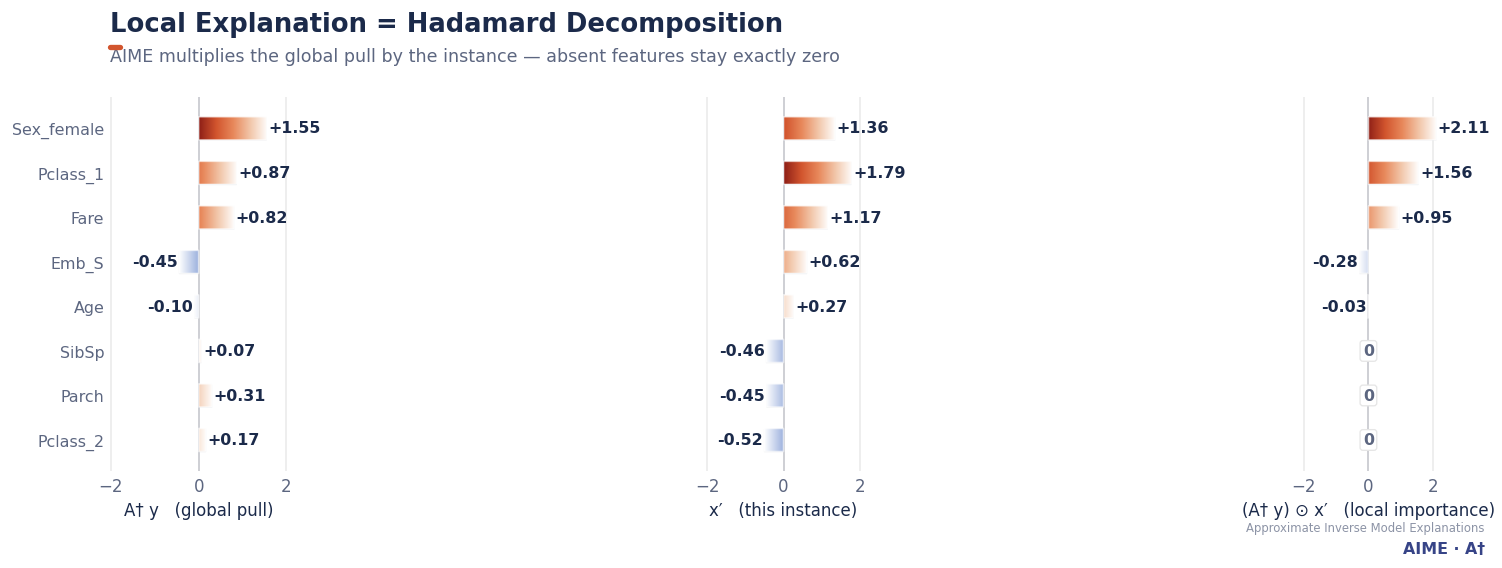

,pull,x,prod
Pclass_2,0.172136,-0.517254,-0.000000
Parch,0.310558,-0.451483,-0.000000
SibSp,0.070662,-0.464720,-0.000000
Age,-0.098372,0.265727,-0.026140
Emb_S,-0.452479,0.623517,-0.282129
Fare,0.817594,1.166592,0.953799
Pclass_1,0.872814,1.789206,1.561644
Sex_female,1.551197,1.361874,2.112535


In [9]:
explainer.plot_local_hadamard_decomposition(
    focus_x,
    focus_y,
    feature_names=feature_names,
    scaler=explainer.scaler,
    top_k=8,
    ignore_zero_features=True,
)


## 6. Representative input patterns and inverse-operator flow

`A† eₜ` is the representative input pattern reconstructed for a pure output of class `t`. This is an input-side object derived directly from the inverse operator.


In [10]:
representatives = explainer.representative_instance(
    feature_names=feature_names,
    class_names=class_names,
)
display(representatives.round(2))


,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Emb_C,Emb_Q,Emb_S
not survived,30.36,0.42,0.21,6.63,0.00,0.17,0.83,-0.12,1.12,0.08,0.07,0.85
survived,28.25,0.54,0.64,70.65,0.62,0.28,0.10,1.10,-0.10,0.39,0.10,0.51


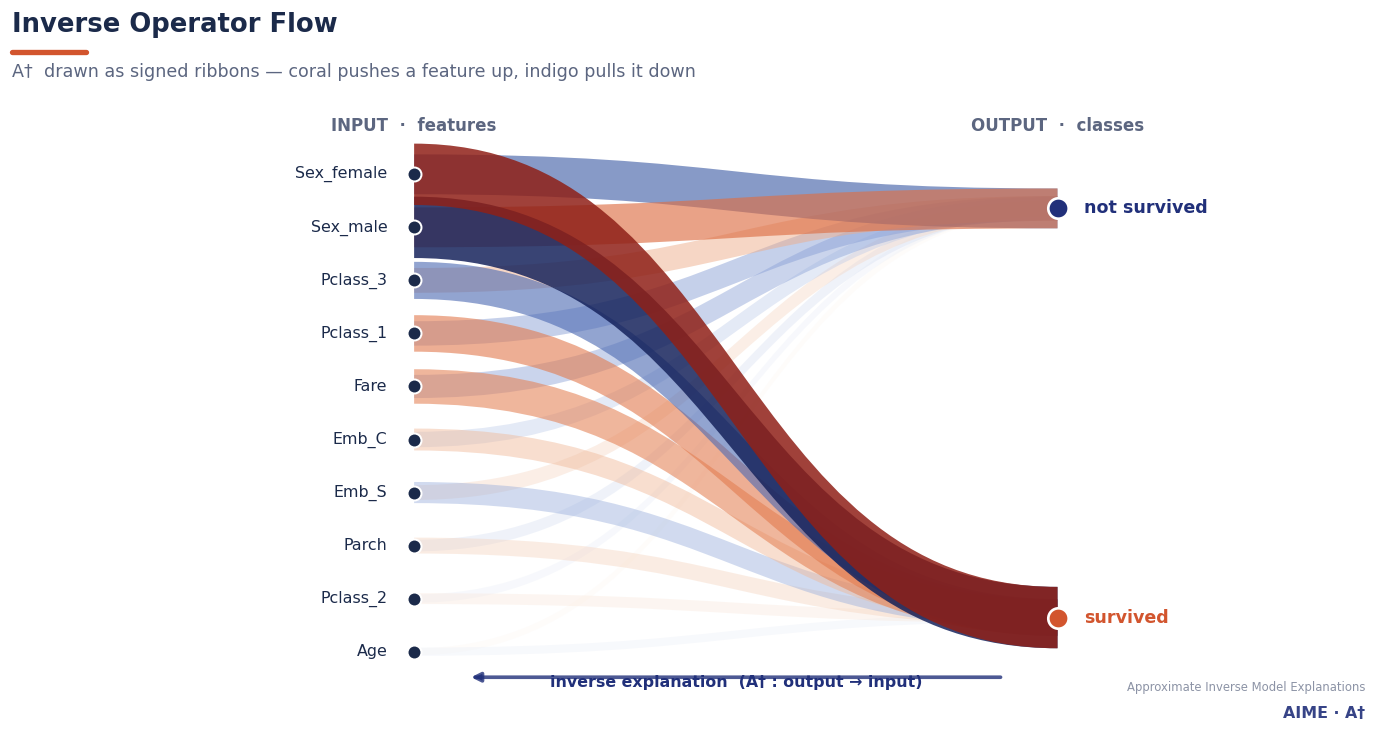

,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Emb_C,Emb_Q,Emb_S
not survived,0.062289,-0.044743,-0.196644,-0.517698,-0.552662,-0.108996,0.562608,-0.982212,0.982212,-0.299809,-0.032695,0.286508
survived,-0.100157,0.071944,0.316192,0.832427,0.888648,0.175259,-0.904641,1.579339,-1.579339,0.482076,0.052571,-0.460688


In [11]:
explainer.plot_inverse_operator_flow(
    feature_names=feature_names,
    class_names=class_names,
    top_k=10,
)


## 7. Optional: interactive inverse-operator explorer

Hover over a class node to trace its strongest inverse-operator connections back to the input features.


In [12]:
explainer.interactive_operator_flow(
    feature_names=feature_names,
    class_names=class_names,
    top_k=10,
)


---

### Takeaway

AIME fits one `A†` and reads it at several levels: global class structure, one-instance local contributions, representative inputs, and operator-level flow. The methodology is described in the [original AIME paper](https://ieeexplore.ieee.org/document/10247033).
